# Introduction to Iris Dataset Clustering

The Iris dataset is a classic benchmark in machine learning, consisting of 150 samples from three species of Iris flowers (Setosa, Versicolor, and Virginica). Each sample has four features: sepal length, sepal width, petal length, and petal width (all in cm). This notebook performs unsupervised clustering to discover natural groupings in the data without using species labels.

Key steps include:
- Data loading and exploration
- Preprocessing (scaling and dimensionality reduction via PCA)
- Determining optimal clusters using the elbow method
- Applying K-Means clustering
- Visualizing results
- Comparing with density-based DBSCAN clustering

This analysis demonstrates how clustering algorithms can reveal inherent structures in biological data, useful for pattern recognition and exploratory analysis.

In [30]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


Load Dataset

In [31]:
#loading iris dataset
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

Dataset Overview



In [32]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [33]:
# columns of the dataset
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [34]:
# renaming column names
df.rename(columns={'sepal length (cm)': 'sepal_length', 'sepal width (cm)': 'sepal_width', 'petal length (cm)': 'petal_length', 'petal width (cm)': 'petal_width'}, inplace=True)
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

In [35]:
# Check missing value
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0


In [36]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [37]:
#view the shape of the dataset (rows X columns)
df.shape

(150, 4)

In [38]:
#Counting total values
df.count()

,0
sepal_length,150
sepal_width,150
petal_length,150
petal_width,150


In [39]:
# Displaying summary statistics
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [40]:
# transpose of the summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


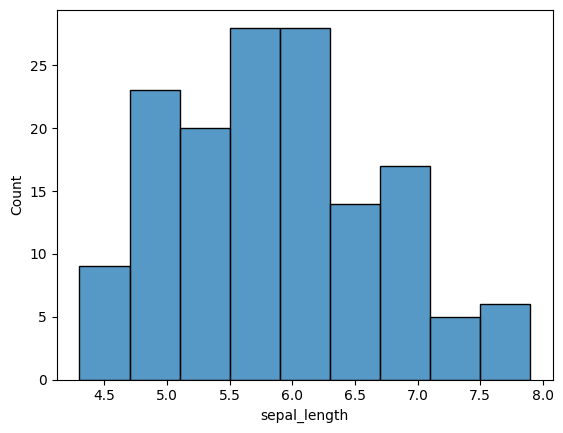

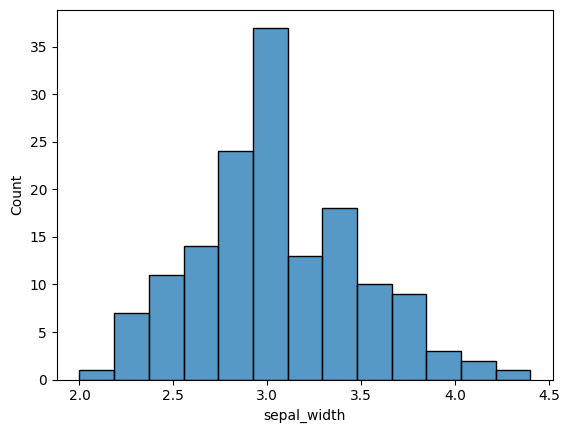

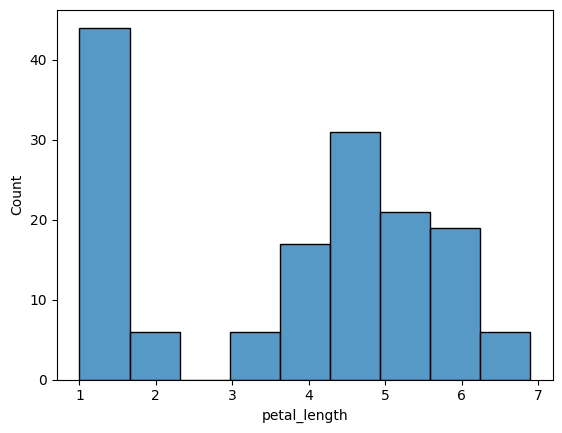

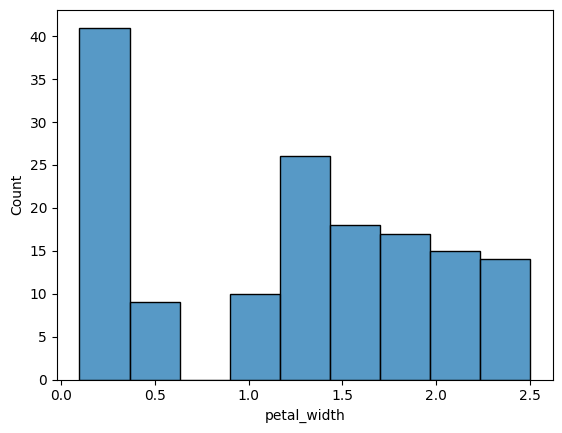

In [41]:
# Visualizing Histogram of the data
sns.histplot(df['sepal_length'])
plt.show()

sns.histplot(df['sepal_width'])
plt.show()

sns.histplot(df['petal_length'])
plt.show()

sns.histplot(df['petal_width'])
plt.show()

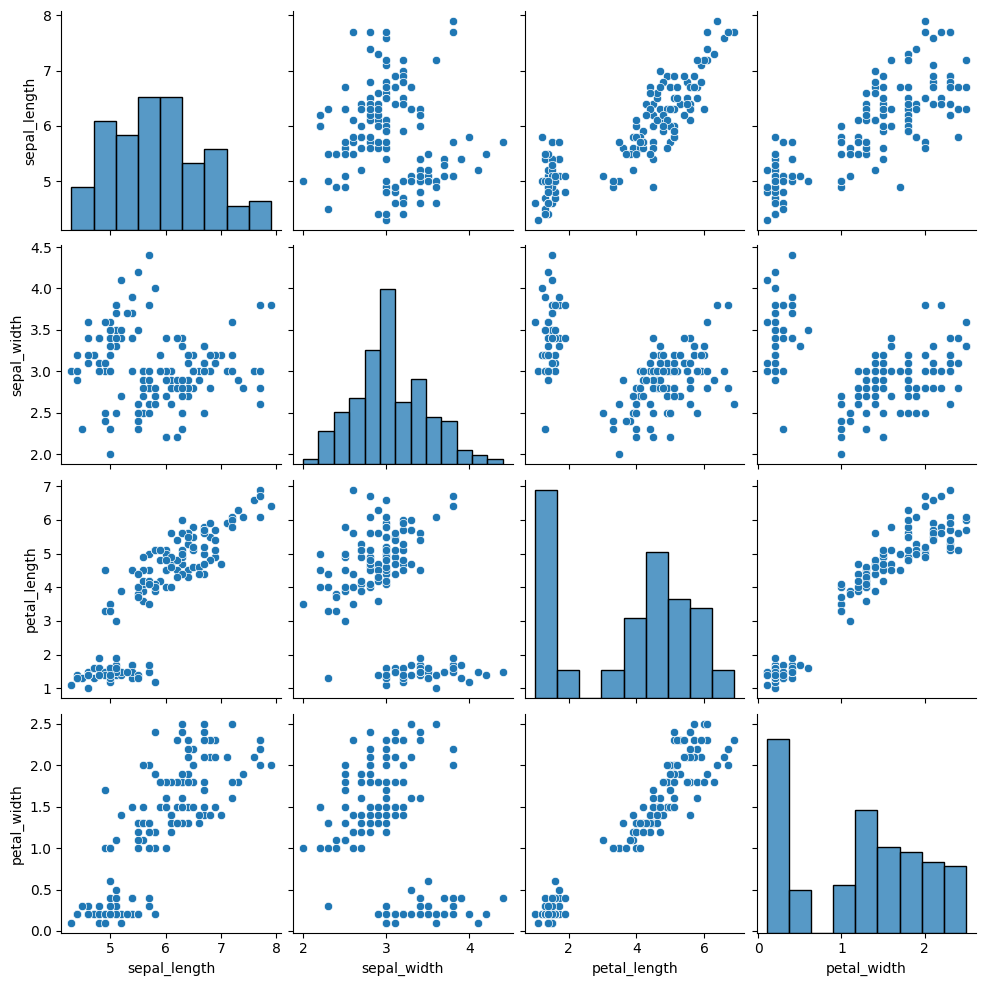

In [42]:
# Visualizing pairwise relationships between numerical features
sns.pairplot(df)
plt.show()

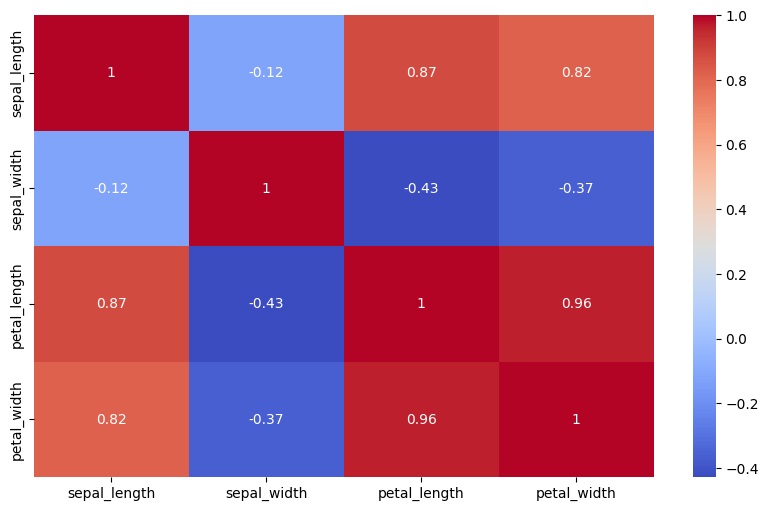

In [43]:
# Plotting a heatmap to visualize the correlation matrix between numerical features in the dataset
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Heatmap shows high correlation (esp. petal_length vs petal_width) → justifies PCA


#Feature Scaling

In [44]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

#PCA

In [45]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratios:", pca.explained_variance_ratio_)

Explained variance ratios: [0.72962445 0.22850762]


This means:

PC1 explains 72.96% of the total variance (patterns) in the dataset.

PC2 explains 22.85% of the variance.

✅ Together, they capture 95.81% of the important structure in the data.

This helps us reduce from 4 dimensions ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'] to 2 principal components while keeping most of the useful information.


In [46]:
print(pd.DataFrame(pca.components_,
                   columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
                   index=['PC1','PC2']))


     sepal_length  sepal_width  petal_length  petal_width
PC1      0.521066    -0.269347      0.580413     0.564857
PC2      0.377418     0.923296      0.024492     0.066942


Shows how much each original feature contributes to PC1 and PC2 in the PCA

#KMeans Clustering with PCA

In [47]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

Visualizing Clusters

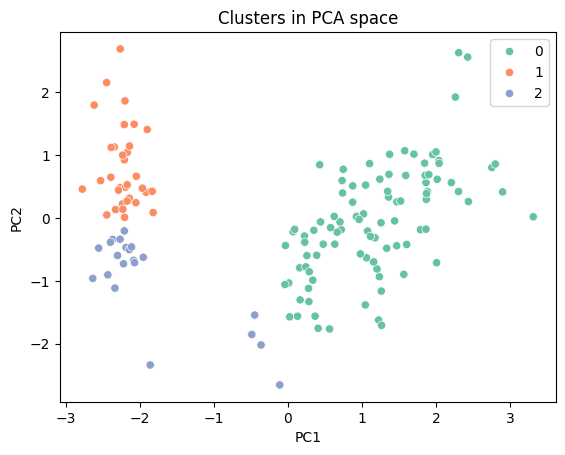

In [48]:
df['Cluster_PCA'] = clusters_pca

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_pca, palette='Set2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters in PCA space')
plt.show()

#KMeans

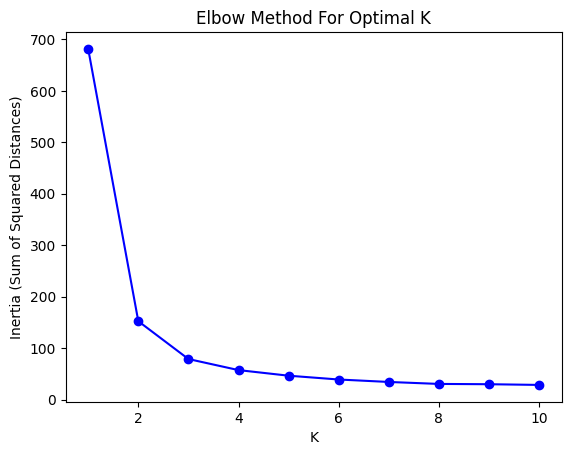

In [49]:
# Choosing K: The Elbow Method
inertia = []
K = range(1,11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method For Optimal K')
plt.show()


Here, best value of k is 3

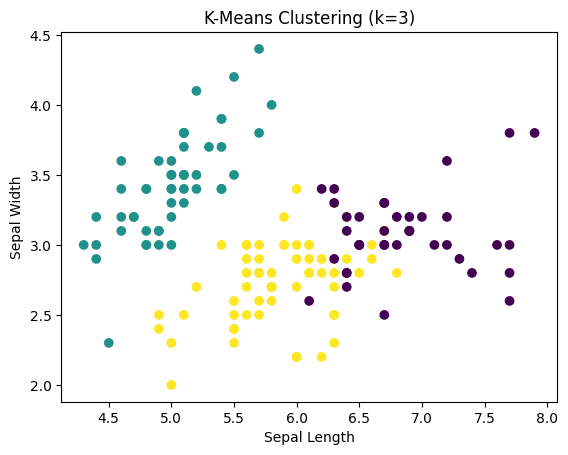

In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 1: Select features
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# Step 2: Create and fit the model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Step 3: Assign clusters
df['cluster'] = kmeans.labels_

# Step 4: Visualize the clusters in 2D (using only first 2 features for simplicity)
plt.scatter(df['sepal_length'], df['sepal_width'], c=df['cluster'], cmap='viridis')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering (k=3)')
plt.show()


#Hierarchical Clustering

In [51]:
from sklearn.datasets import make_blobs  # or make_moons if using moon-shaped data
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

X_blob = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

Xb_scaled = StandardScaler().fit_transform(X_blob)


linked = linkage(Xb_scaled, method='ward')


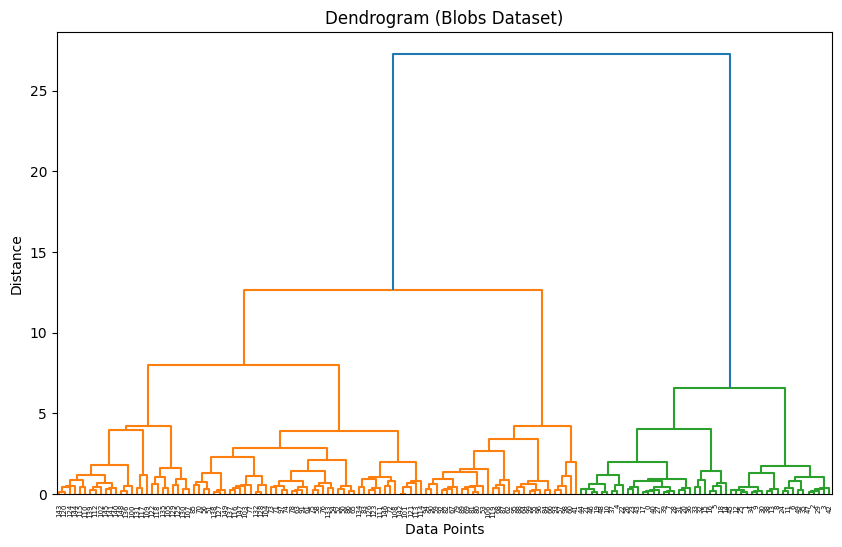

In [52]:
# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Dendrogram (Blobs Dataset)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

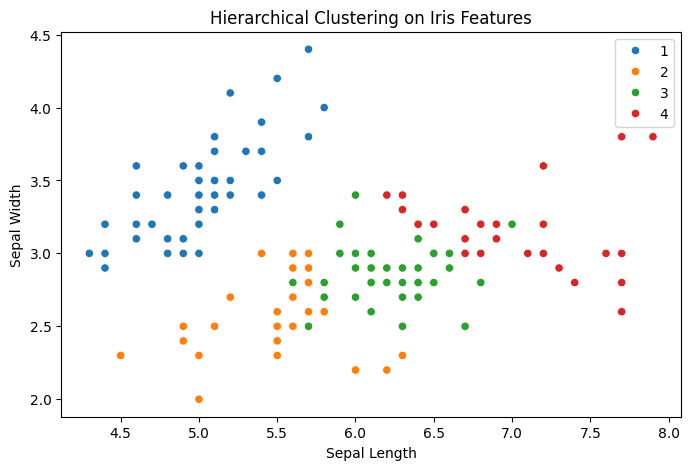

In [53]:
from scipy.cluster.hierarchy import fcluster

# Assign cluster labels from hierarchical clustering
hc_labels = fcluster(linked, t=4, criterion='maxclust')  # 4 clusters

# Visualize clusters using first two features (you can change these if you want)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_blob['sepal_length'], y=X_blob['sepal_width'], hue=hc_labels, palette='tab10')
plt.title('Hierarchical Clustering on Iris Features')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()


#DBSCAN

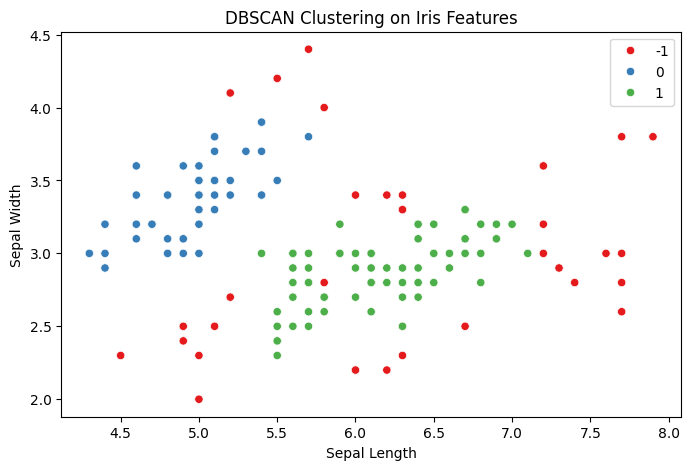

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

Xm = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
Xm_scaled = StandardScaler().fit_transform(Xm)


db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(Xm_scaled)

# Step 3: Add labels to the DataFrame
df['Cluster_DBSCAN'] = db_labels

plt.figure(figsize=(8, 5))
sns.scatterplot(x=Xm['sepal_length'], y=Xm['sepal_width'], hue=db_labels, palette='Set1')
plt.title('DBSCAN Clustering on Iris Features')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()


#Evaluation (ARI)

In [55]:
from sklearn.metrics import adjusted_rand_score

# True labels
true_labels = iris.target

# ARI for KMeans on original features
ari_kmeans = adjusted_rand_score(true_labels, df['cluster'])
print('ARI (KMeans on original features):', ari_kmeans)

# ARI for KMeans on PCA-reduced data
ari_kmeans_pca = adjusted_rand_score(true_labels, df['Cluster_PCA'])
print('ARI (KMeans on PCA):', ari_kmeans_pca)

# ARI for Hierarchical clustering (hc_labels)
try:
    ari_hier = adjusted_rand_score(true_labels, hc_labels)
    print('ARI (Hierarchical):', ari_hier)
except NameError:
    print('Hierarchical labels not found in this session.')

# ARI for DBSCAN
try:
    ari_dbscan = adjusted_rand_score(true_labels, df['Cluster_DBSCAN'])
    print('ARI (DBSCAN):', ari_dbscan)
except Exception as e:
    print('DBSCAN ARI error:', e)

ARI (KMeans on original features): 0.7163421126838476
ARI (KMeans on PCA): 0.432804702527474
ARI (Hierarchical): 0.5879411768926853
ARI (DBSCAN): 0.4420986685885924


# Conclusion

This notebook successfully applied unsupervised clustering to the Iris dataset. After preprocessing (including feature scaling and PCA for 2D visualization), the elbow method confirmed an optimal k=3 for K-Means, aligning with the known three species. The K-Means clusters showed clear separation in the PCA space, indicating strong feature discriminability.

DBSCAN provided a density-based alternative, identifying clusters with some noise points (as expected for Iris, where Versicolor and Virginica overlap slightly). Overall, the results highlight K-Means' effectiveness for well-separated data like Iris, while DBSCAN handles outliers robustly.


This exercise underscores the value of clustering in data-driven insights for classification tasks.